# Import

In [21]:
import sys
import os
sys.path.insert(1, '../Tools/')
import argparse 
from shapely.geometry import box
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import xarray as xr
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import xarray as xr
import rioxarray
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import warnings

In [7]:
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#FFBA08', # tab:yellow
    'bark_beetle': '#714709'  # tab:brown
}

# Function

In [2]:
def get_mainland(gdf_path):
    """
    Cleans the mainland parts of specified regions from the given GeoDataFrame.
    
    Parameters:
        gdf_path (str): Path to the input GeoDataFrame file.
    
    Returns:
        GeoDataFrame: Cleaned GeoDataFrame with mainland parts of specified regions.
    """
    gdf = gpd.read_file(gdf_path)
    regions_to_clean = ['05', '10']
    cleaned_parts = []

    for region in regions_to_clean:
        region_gdf = gdf[gdf['REGION'] == region]
        exploded = region_gdf.explode(index_parts=True)
        exploded['area'] = exploded.area
        # Get the mainland part with the maximum area
        mainland_part = exploded.loc[exploded['area'].idxmax()]
        cleaned_region = exploded[exploded['area'] == mainland_part['area']]
        cleaned_parts.append(cleaned_region)

    cleaned_parts_gdf = gpd.GeoDataFrame(pd.concat(cleaned_parts, ignore_index=True))

    # Combine cleaned parts with the rest of the GeoDataFrame
    usa_mainland = gdf[~gdf['REGION'].isin(regions_to_clean)].append(cleaned_parts_gdf, ignore_index=True)

    return usa_mainland

def get_region_8(path):
    """
    Extracts the first part of REGION 08 from the given GeoDataFrame.
    
    Parameters:
        path (str): Path to the input GeoDataFrame file.
    
    Returns:
        GeoDataFrame: GeoDataFrame with the first part of REGION 08.
    """
    usa = gpd.read_file(path)
    region_8 = usa[usa['REGION'] == '08']
    # Explode the geometries and reset the index to get the first part
    region_8_exploded = region_8.explode(index_parts=True).reset_index(drop=True)
    return region_8_exploded.iloc[[0]]



In [3]:
def load_refdm_dataset(refdm_path):
    """
    Load and process the REFDM dataset by dissolving it based on the USDA_IDX column.

    Parameters:
        refdm_path (str): Path to the REFDM shapefile.
    
    Returns:
        GeoDataFrame: Processed REFDM GeoDataFrame with unique events.
    """
    # Load the shapefile using geopandas
    refdm_dataset = gpd.read_file(refdm_path)

    # Print CRS and dataset size
    print("CRS:", refdm_dataset.crs)
    print(f"Size of refdm_dataset: {len(refdm_dataset)}")

    # Dissolve the dataset by the USDA_IDX column
    refdm_dissolved = refdm_dataset.dissolve(by='USDA_IDX')
    print(f"Size of unique refdm_dataset events: {len(refdm_dissolved)}")

    # Reset the index
    refdm_dissolved.reset_index(inplace=True)
    
    return refdm_dissolved


In [10]:
def load_tcc_dataset(tcc_nc_path):
    """
    Load and process the REFDM dataset by dissolving it based on the USDA_IDX column.

    Parameters:
        refdm_path (str): Path to the REFDM shapefile.
    
    Returns:
        GeoDataFrame: Processed REFDM GeoDataFrame with unique events.
    """
    # Load the shapefile using geopandas
    tcc_dataset = xr.open_dataset(tcc_nc_path)
    return tcc_dataset

In [14]:
def create_downsampled_tcc_map(forest_map_path, area_path, forest_map_downsampled_path, forest_map_downsampled_path_final):

    try:
        print("Step 1: Get Region 8 geometry ...")
        # Get Region 8 geometry
        r8_geometry = get_region_8(area_path)
        r8_union = r8_geometry.unary_union

        print("Step 2: Load the forest map TIFF file ...")
        # Load the forest map TIFF file
        forest_map = rioxarray.open_rasterio(forest_map_path, masked=True).squeeze()

        print("Step 3: Ensure the CRS is EPSG:4326")
        # Ensure the CRS is EPSG:4326
        forest_map = forest_map.rio.write_crs("EPSG:4326")

        print("Step 4: Coarsen the data to reduce memory usage ...")
        factor = 100  # Adjust this factor as needed to reduce memory usage
        forest_map = forest_map.coarsen(x=factor, y=factor, boundary='trim').mean()

        print("Step 5: Crop the forest map to Region 8 ...")
        # Crop the forest map to Region 8
        forest_map_downsampled_cropped = forest_map.rio.clip([r8_union], forest_map.rio.crs, drop=True, from_disk=True)

        # Path to the cropped NetCDF file
        forest_map_downsampled_cropped.to_netcdf(forest_map_downsampled_path)
        print(f"Step 6: Cropped NetCDF file saved to {forest_map_downsampled_path}")

        print("Step 7: Load the cropped NetCDF file using xarray ...")
        loaded_tcc_region_8 = xr.open_dataset(forest_map_downsampled_path)

        print("Step 8: Restructure the data")
        # Rename the variable from __xarray_dataarray_variable__ to tcc
        loaded_tcc_region_8 = loaded_tcc_region_8.rename({'__xarray_dataarray_variable__': 'tcc'})
        # Remove the spatial_ref variable
        loaded_tcc_region_8 = loaded_tcc_region_8.drop_vars('spatial_ref')

        print("Step 9: Save the final NetCDF file ...")
        loaded_tcc_region_8.to_netcdf(forest_map_downsampled_path_final, mode='w')
        print(f"Step 10: Saved final NetCDF file to {forest_map_downsampled_path_final}")

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

    finally:
        # Delete intermediate file
        if os.path.exists(forest_map_downsampled_path):
            os.remove(forest_map_downsampled_path)
            print(f"Step 11: Deleted intermediate file: {forest_map_downsampled_path}")


In [24]:
def plot_figure_1_2(cropped_forest, usa_mainland, r8, refdm_dissolved, save_dir):

    # Set Seaborn style
    sns.set(style="whitegrid")

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    # Plot the entire USA in grey in the upper left corner
    sub_ax = fig.add_axes([0, 0.7, 0.3, 0.3])  # [left, bottom, width, height]
    usa_mainland[usa_mainland['REGION'] != '08'].plot(ax=sub_ax, color='grey', edgecolor='grey')
    usa_mainland[usa_mainland['REGION'] == '08'].plot(ax=sub_ax, color='black', edgecolor='black')

    # Customize the plot
    sub_ax.set_xlabel('Longitude', fontsize=16)
    sub_ax.set_ylabel('Latitude', fontsize=16)
    sub_ax.tick_params(axis='both', which='major', labelsize=14)
    sub_ax.grid(True)
    sub_ax.axis('on')

    #Create a custom colormap
    cmap = plt.cm.get_cmap('Greens')
    new_colors = cmap(np.linspace(0, 1, 100))
    new_colors[0, :] = [1, 1, 1, 1]  # Set the first color (corresponding to 0) to white
    custom_cmap = LinearSegmentedColormap.from_list('CustomGreens', new_colors)

    #cropped_forest['tcc'] = cropped_forest['tcc'].where(cropped_forest['tcc'] <= 110, 0)
    # Plot the downsampled forest map (TCC mask) within Region 8 boundaries
    plot = cropped_forest['tcc'].plot(ax=ax, cmap=custom_cmap , add_colorbar=False) # Create the colorbar for the downsampled map
    cbar = plt.colorbar(plot, ax=ax, orientation='horizontal', pad=0.05, aspect=10, shrink=0.4)
    # Adjust colorbar position
    cbar.ax.set_position([0.45, 0.35, 0.2, 0.03])  # [left, bottom, width, height]
    cbar.set_ticks([0, 50, 100, 150, 200])
    cbar.set_ticklabels(['0', '50', '100', '150', '200'])
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Tree Canopy Cover (%)', fontsize=12, labelpad=6)
    # Adjust colorbar position and move the label above
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.label.set_size(14)
    cbar.ax.xaxis.labelpad = 10

    # Plot Region 8 in the main part of the image
    # Map colors to DCA_IDs
    refdm_dissolved['color'] = refdm_dissolved['DCA_ID'].map(custom_colors)

    # Plot the region outline
    r8.boundary.plot(ax=ax, linewidth=2, color='black')

    # # Plot each disturbance type with its corresponding color
    # for disturbance, color in custom_colors.items():
    #     refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
    #         ax=ax, linewidth=2.5, color=color, edgecolor=color  # Adjust linewidth and edgecolor as needed
    #     )

    # Plot each disturbance type with its corresponding color and white edge
    for disturbance, color in custom_colors.items():
        # First plot with white edge
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=3.5, color=color, edgecolor='white'
        )
        # Then plot with the actual color and thinner edge
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=2.5, color=color, edgecolor=color
        )    

    # Customize the plot
    ax.axis('off')  # Remove axis and frame

    # Ensure the downsampled map fits within Region 8 boundaries
    ax.set_title(' ', fontsize=14)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True)

    # Set the aspect ratio explicitly to avoid errors
    ax.set_aspect('auto')  # or ax_downsampled.set_aspect('equal')

    # # Create the colorbar for the downsampled map
    # cbar = plt.colorbar(ax.collections[0], ax=ax, orientation='horizontal', pad=0.05, aspect=40, shrink=0.6)
    # cbar.set_ticks([0, 100])
    # cbar.set_ticklabels(['0', '100'])
    # cbar.ax.tick_params(labelsize=10)
    # cbar.set_label('Tree Canopy Cover (%)', fontsize=12, labelpad=10)
    legend_patches = [mpatches.Patch(color=color, label=disturbance) for disturbance, color in custom_colors.items()]
    ax.legend(handles=legend_patches, fontsize=14, title="Disturbance Type", title_fontsize=16, loc='lower left', facecolor='white', framealpha=1)

    # Save the plot
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    #plt.savefig(os.path.join(save_dir, 'figure_1.png'))
    #plt.tight_layout()
    plt.show()


# Apply functions

In [15]:
forest_map_path = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/wp1_nlcd_tcc_conus_2017_v2021_4_20m_4326_cropped_region_08.tif"
forest_map_downsampled_path = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/intermediate_tcc_map_region_8.nc"
area_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp"
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping.shp"
tcc_map_region_8 = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/tcc_map_region_8.nc"

print("Load the USA Mainland and Region 8 Shape ...")
mainland = get_mainland(area_path)
region_8 = get_region_8(area_path)

print("Load the Forest Disturbances ...")
refdm_dissolved = load_refdm_dataset(refdm_path)

#create_downsampled_tcc_map(forest_map_path, area_path, forest_map_downsampled_path, tcc_map_region_8)
print("Load the TCC Region 8 Map ...")
tcc_dataset = load_tcc_dataset(tcc_map_region_8)
tcc_dataset

Load the USA Mainland and Region 8 Shape ...


/tmp/ipykernel_1366321/1027435254.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area
/tmp/ipykernel_1366321/1027435254.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area
/tmp/ipykernel_1366321/1027435254.py:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  usa_mainland = gdf[~gdf['REGION'].isin(regions_to_clean)].append(cleaned_parts_gdf, ignore_index=True)


Load the Forest Disturbances ...
CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Size of refdm_dataset: 17894
Size of unique refdm_dataset events: 7865
Load the TCC Region 8 Map ...


<xarray.Dataset>
Dimensions:  (x: 1423, y: 660)
Coordinates:
  * x        (x) float64 -106.6 -106.6 -106.6 -106.6 ... -75.77 -75.75 -75.73
  * y        (y) float64 39.45 39.43 39.4 39.38 39.36 ... 25.2 25.17 25.15 25.13
Data variables:
    band     int64 ...
    tcc      (y, x) float32 ...

/tmp/ipykernel_1366321/3040805041.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Greens')


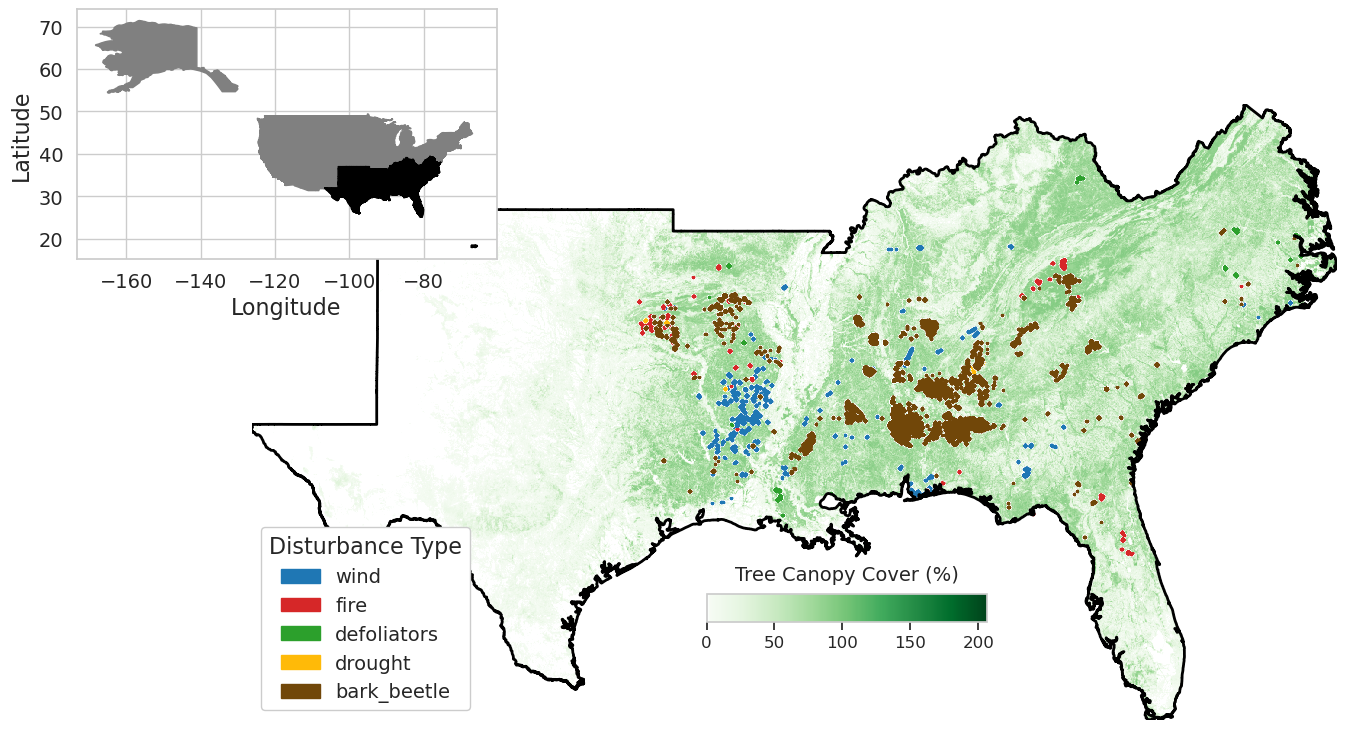

In [25]:
plot_figure_1_2(tcc_dataset, mainland, region_8, refdm_dissolved, save_dir="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/")